# 02 — Building the windowed dataset from scratch

Notebook 01 measured the raw data and produced a list of decisions. This notebook turns them into the
dataset everything else in Session 3 trains and is scored on.

**What is built**

| | |
|---|---|
| unit | one **(job, node) series**, windowed independently |
| window | 40 snapshots = **20 minutes**, rejected if it contains a gap > 60 s |
| stride | **5 on train** (39/40 overlap is redundant), **1 on test** (keeps the test population and its PR-AUC baseline comparable with Sessions 1–2) |
| metrics | **39** — the 8 inherited ones, every counter as a rate, unused GPU telemetry, host-health signals |
| aggregations | **7** — `min max mean std` (as before) plus `last delta slope` (the trajectory) |
| columns | 39 × 7 = **273** |
| labels | positive iff the job ends in a failure state and ≥ 20 of the window's 40 snapshots fall inside the 2 h pre-end horizon |

**What is stored alongside every window** — this is what keeps the pipeline honest later:
`y`, `job_id` (grouping), `node_id` (per-node normalisation), `state` (per-state recall),
`t_end` (the window's last timestamp — every split, fold and embargo is expressed in it) and
`ttf_end` (seconds from that timestamp to the job's end — lets any horizon be re-derived without a rebuild).

The build streams the 10 GB parquet partition by partition and appends straight to disk, so peak memory is
about one partition rather than the whole frame.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()
print(f"{len(pv2.METRICS)} metrics x {len(pv2.AGGS)} aggregations = "
      f"{len(pv2.feature_names())} columns, from {len(pv2.source_columns())} parquet columns")

39 metrics x 7 aggregations = 273 columns, from 36 parquet columns


## 1. The metric registry

Three kinds of metric. `raw` is a column taken as it is. `rate` is a cumulative counter turned into a
per-second first difference (negative steps are counter resets and are clipped to zero; the first snapshot
of a series is back-filled). `spread` is a max − min across the node's GPUs — one sick card inside an
otherwise healthy node shows up there and nowhere else.

The `v1` group reproduces Session 1's eight metrics **exactly**, counters included. That is deliberate:
rung A of the ablation has to be a faithful replica before any later change can be credited to the changes.

In [2]:
reg = pd.DataFrame([(n, pv2.METRIC_GROUP[n], k, s if isinstance(s, str) else " - ".join(s))
                    for n, k, s in pv2.METRICS],
                   columns=["metric", "group", "kind", "source column(s)"])
for grp in ("v1", "rate", "gpu", "node"):
    sub = reg[reg.group == grp]
    print(f"--- {grp} ({len(sub)}) " + "-" * 60)
    print(sub[["metric", "kind", "source column(s)"]].to_string(index=False))
print(f"\ntotal metrics: {len(reg)}")

--- v1 (8) ------------------------------------------------------------
          metric kind                       source column(s)
      mem_active  raw               node_memory_Active_bytes
disk_written_cum  raw      node_disk_written_bytes_total_sum
  tcp_inerrs_cum  raw                node_netstat_Tcp_InErrs
       forks_cum  raw                       node_forks_total
   gpu_temp_mean  raw    nvidia_gpu_temperature_celsius_mean
  gpu_power_mean  raw nvidia_gpu_power_usage_milliwatts_mean
    gpu_mem_used  raw       nvidia_gpu_memory_used_bytes_sum
    gpu_fan_mean  raw       nvidia_gpu_fanspeed_percent_mean
--- rate (13) ------------------------------------------------------------
           metric kind                      source column(s)
disk_written_rate rate     node_disk_written_bytes_total_sum
  tcp_inerrs_rate rate               node_netstat_Tcp_InErrs
       forks_rate rate                      node_forks_total
       ctxsw_rate rate           node_context_switches_total

## 2. Why `last`, `delta` and `slope`

`min/max/mean/std` are *order-blind*: shuffle the 40 snapshots of a window and they do not change. A
window in which memory climbs steadily towards exhaustion and one in which it falls back to normal can
have identical summaries. Failure is a process — it has a direction — so the summary should keep one.

Three cheap additions recover it: `last` (where the metric is *now*, not where it averaged), `delta`
(end minus start) and `slope` (the least-squares trend, in units per second — well defined precisely
because the gap guard leaves every window on an even 30 s grid).

 window    min    max   mean    std    last    delta  slope/s
 rising 0.0377 10.448 4.9819 2.9965 10.4480  10.4103   0.0086
falling 0.0377 10.448 4.9819 2.9965  0.0377 -10.4103  -0.0086


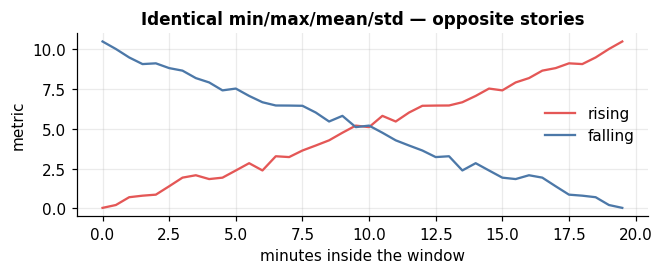

In [3]:
rise = np.linspace(0, 10, pv2.WINDOW) + np.random.default_rng(0).normal(0, .3, pv2.WINDOW)
fall = rise[::-1]
w = pv2.slope_weights()
rows = []
for name, v in (("rising", rise), ("falling", fall)):
    rows.append({"window": name, "min": v.min(), "max": v.max(), "mean": v.mean(),
                 "std": v.std(), "last": v[-1], "delta": v[-1] - v[0], "slope/s": w @ v})
print(pd.DataFrame(rows).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 2.6))
mins = np.arange(pv2.WINDOW) * pv2.SNAP_SECONDS / 60
ax.plot(mins, rise, label="rising", color=pv2.PALETTE["accent"])
ax.plot(mins, fall, label="falling", color=pv2.PALETTE["rate"])
ax.set_xlabel("minutes inside the window"); ax.set_ylabel("metric")
ax.set_title("Identical min/max/mean/std — opposite stories")
ax.legend()
fig.savefig(pv2.FIGURES / "02_why_trajectory.png", bbox_inches="tight")
plt.show()

## 3. Run the build

Roughly four minutes and ~3.5 GB on disk. It is cached: re-running the notebook does not rebuild.

In [4]:
t0 = time.time()
meta = pv2.build_dataset(tag="primary")
print(f"\n{time.time()-t0:.0f}s")
print(json.dumps({k: v for k, v in meta.items() if k not in ("features",)}, indent=2)[:1200])

dataset 'primary' already built -> D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\artifacts\primary

1s
{
  "tag": "primary",
  "window": 40,
  "horizon_h": 2.0,
  "aggs": [
    "min",
    "max",
    "mean",
    "std",
    "last",
    "delta",
    "slope"
  ],
  "metrics": [
    "mem_active",
    "disk_written_cum",
    "tcp_inerrs_cum",
    "forks_cum",
    "gpu_temp_mean",
    "gpu_power_mean",
    "gpu_mem_used",
    "gpu_fan_mean",
    "disk_written_rate",
    "tcp_inerrs_rate",
    "forks_rate",
    "ctxsw_rate",
    "intr_rate",
    "disk_read_rate",
    "disk_wcompl_rate",
    "net_tx_rate",
    "net_rx_rate",
    "net_rxdrop_rate",
    "tcp_retrans_rate",
    "icmp_inerr_rate",
    "rapl_power",
    "gpu_duty_mean",
    "gpu_duty_min",
    "gpu_temp_max",
    "gpu_temp_spread",
    "gpu_power_max",
    "gpu_power_spread",
    "gpu_fan_max",
    "mem_free",
    "mem_dirty",
    "load1",
    "load15",
    "procs_running",
    "procs_blocked",
    "hwmon_temp_max",
    "thermal_max

In [5]:
data = {s: pv2.load_dataset("primary", s) for s in ("train", "test")}
rows = []
for s, d in data.items():
    X = d["X"]
    rows.append({"split": s, "windows": X.shape[0], "columns": X.shape[1],
                 "positives": int(d["y"].sum()), "pos_fraction": float(d["y"].mean()),
                 "jobs": int(np.unique(d["job_id"]).size),
                 "nodes": int(np.unique(d["node_id"]).size),
                 "GB on disk": X.nbytes / 1e9})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nPR-AUC baseline (test positive fraction) = {data['test']['y'].mean():.4f}")
print("Sessions 1-2 reported 0.0403 on their test set; 0.0795-0.0860 was the best PR-AUC there.")

split  windows  columns  positives  pos_fraction  jobs  nodes  GB on disk
train  1825415      273      58835        0.0322 10265     51      1.9934
 test  1407162      273      56527        0.0402  2694     49      1.5366

PR-AUC baseline (test positive fraction) = 0.0402
Sessions 1-2 reported 0.0403 on their test set; 0.0795-0.0860 was the best PR-AUC there.


## 4. Verification

A build is only as good as its checks. Five, all of them assertions rather than eyeballing:

1. the window counts are exactly what the timestamps predict, recomputed independently here;
2. every side array is aligned 1:1 with `X`;
3. `t_end` never runs backwards inside a series, and train `t_end` never reaches into the test period;
4. no job appears in both splits;
5. the stored labels equal the ones re-derived in closed form from `ttf_end` — which is what licenses the
   horizon experiments in notebook 05.

In [6]:
sc, jt = pv2.build_scaffold(verbose=False)
sid = sc["series_id"].to_numpy(); jid = sc["slurm_id"].to_numpy()
ts = sc["timestamp"].to_numpy("datetime64[ns]").astype(np.int64)
new = np.r_[True, sid[1:] != sid[:-1]]
st_idx = np.flatnonzero(new); en_idx = np.r_[st_idx[1:], len(sid)]
split_of = {int(k): v for k, v in jt.set_index("slurm_id")["split"].items()}
strides = {"train": meta["stride_train"], "test": meta["stride_test"]}

expected = {"train": 0, "test": 0}
for s0, e0 in zip(st_idx, en_idx):
    sp = split_of[int(jid[s0])]
    expected[sp] += len(pv2.valid_window_starts(ts[s0:e0], meta["window"], strides[sp]))
for s in ("train", "test"):
    got = data[s]["X"].shape[0]
    print(f"[1] {s}: built {got:,} windows, timestamps predict {expected[s]:,}")
    assert got == expected[s]

for s, d in data.items():
    n = d["X"].shape[0]
    for k in ("y", "job_id", "node_id", "state", "t_end", "ttf_end"):
        assert len(d[k]) == n, (s, k)
print("[2] every side array aligned 1:1 with X")

for s, d in data.items():
    j = d["job_id"]; t = d["t_end"]
    same = np.r_[False, (j[1:] == j[:-1]) & (d["node_id"][1:] == d["node_id"][:-1])]
    assert (np.diff(t)[same[1:]] > 0).all(), f"{s}: t_end not increasing inside a series"
print(f"[3] t_end monotone inside every series; "
      f"train ends {pd.to_datetime(data['train']['t_end'].max())}, "
      f"test starts {pd.to_datetime(data['test']['t_end'].min())}")

overlap = set(np.unique(data["train"]["job_id"])) & set(np.unique(data["test"]["job_id"]))
assert not overlap
print(f"[4] no job in both splits ({len(np.unique(data['train']['job_id'])):,} train jobs, "
      f"{len(np.unique(data['test']['job_id'])):,} test jobs)")

for s, d in data.items():
    y2 = pv2.relabel(d["ttf_end"], d["state"], window=meta["window"],
                     horizon_h=meta["horizon_h"])
    assert (y2 == d["y"]).all(), s
print("[5] closed-form re-labelling reproduces the stored labels exactly "
      "-> any horizon can be tested without a rebuild")

[1] train: built 1,825,415 windows, timestamps predict 1,825,415
[1] test: built 1,407,162 windows, timestamps predict 1,407,162
[2] every side array aligned 1:1 with X
[3] t_end monotone inside every series; train ends 2022-10-19 11:47:30, test starts 2022-10-15 16:11:00
[4] no job in both splits (10,265 train jobs, 2,694 test jobs)


[5] closed-form re-labelling reproduces the stored labels exactly -> any horizon can be tested without a rebuild


## 5. What the windows look like

Positives by job state, and a first look at whether the new trajectory features carry anything: the
distribution of the GPU-temperature slope in positive versus negative test windows.

In [7]:
d = data["test"]
tab = pd.DataFrame({"windows": pd.Series(d["state"]).value_counts(),
                    "positives": pd.Series(d["state"][d["y"] == 1]).value_counts()}).fillna(0)
tab.index = [pv2.STATE_DISPLAY[pv2.CODE_TO_STATE[i]] for i in tab.index]
tab["positive_rate"] = tab.positives / tab.windows
tab["share_of_positives"] = tab.positives / tab.positives.sum()
print(tab.sort_values("positives", ascending=False)
        .assign(windows=lambda x: x.windows.map("{:,.0f}".format),
                positives=lambda x: x.positives.map("{:,.0f}".format),
                positive_rate=lambda x: x.positive_rate.map("{:.3f}".format),
                share_of_positives=lambda x: x.share_of_positives.map("{:.1%}".format)).to_string())

           windows positives positive_rate share_of_positives
TIMEOUT    407,039    39,780         0.098              70.4%
FAILED      51,683    12,674         0.245              22.4%
NODE_FAIL   23,003     2,481         0.108               4.4%
OOM          1,606     1,592         0.991               2.8%
COMPLETED  923,831         0         0.000               0.0%


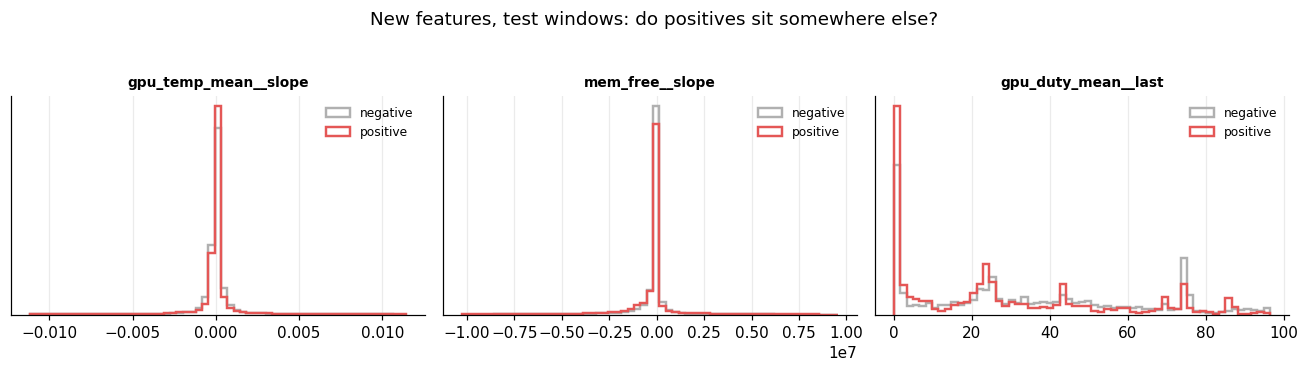

In [8]:
feats = data["test"]["features"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, fname in zip(axes, ["gpu_temp_mean__slope", "mem_free__slope", "gpu_duty_mean__last"]):
    col = feats.index(fname)
    v = pv2.take_columns(d["X"], [col]).ravel()
    lo, hi = np.percentile(v, [1, 99])
    bins = np.linspace(lo, hi, 60)
    ax.hist(v[d["y"] == 0], bins=bins, density=True, histtype="step", lw=1.6,
            label="negative", color=pv2.PALETTE["muted"])
    ax.hist(v[d["y"] == 1], bins=bins, density=True, histtype="step", lw=1.6,
            label="positive", color=pv2.PALETTE["accent"])
    ax.set_title(fname, fontsize=9); ax.set_yticks([]); ax.legend(fontsize=8)
fig.suptitle("New features, test windows: do positives sit somewhere else?", y=1.04)
fig.savefig(pv2.FIGURES / "02_new_feature_separation.png", bbox_inches="tight")
plt.show()

## 6. Per-node baselines

Accumulated during the build over **training snapshots only**, so nothing about the test period leaks into
them. Rung E of the ablation uses them to re-express every feature as a deviation from that node's normal —
and because the snapshot-level transform is affine while the window aggregations are homogeneous, that
rung needs no second pass over the parquet.

In [9]:
b = np.load(pv2.ARTIFACTS / "primary" / "node_baseline.npz", allow_pickle=True)
base = pd.DataFrame(b["mean"], index=b["nodes"], columns=b["metrics"])
sd = pd.DataFrame(b["std"], index=b["nodes"], columns=b["metrics"])
show = ["gpu_temp_mean", "gpu_power_mean", "mem_free", "load1", "gpu_duty_mean"]
print("per-node MEAN of a few metrics (training snapshots only):")
print(base[show].head(6).round(2).to_string())
print("\nspread across nodes (max - min of the per-node mean):")
print((base[show].max() - base[show].min()).round(2).to_string())
print(f"\nnodes with no training snapshots (fall back to the global mean): "
      f"{int((b['std'] == 1.0).all(axis=1).sum())}")

per-node MEAN of a few metrics (training snapshots only):
       gpu_temp_mean  gpu_power_mean      mem_free  load1  gpu_duty_mean
r28n1          56.49       133695.32  1.349908e+11   9.09          38.90
r28n2          56.38       138526.70  9.824348e+10   9.09          38.05
r28n3          58.93       144395.13  1.356984e+11  10.74          46.15
r28n4          58.60       141232.74  1.352597e+11   9.01          41.83
r28n5          58.90       148028.12  1.173480e+11   6.60          43.67
r29n1          54.22       123821.24  1.356719e+11   9.67          35.39

spread across nodes (max - min of the per-node mean):
gpu_temp_mean     4.641000e+01
gpu_power_mean    1.775478e+05
mem_free          1.504239e+12
load1             2.937000e+01
gpu_duty_mean     6.868000e+01

nodes with no training snapshots (fall back to the global mean): 0


## 7. Footprint, and how anything downstream loads this

In [10]:
d0 = pv2.ARTIFACTS / "primary"
files = sorted(d0.iterdir(), key=lambda p: -p.stat().st_size)
print(f"{'file':<26}{'size':>12}")
for p in files:
    print(f"{p.name:<26}{p.stat().st_size/1e6:>10,.1f} MB")
print(f"{'TOTAL':<26}{sum(p.stat().st_size for p in files)/1e9:>10,.2f} GB")
usage = [
    "",
    "    import pv2",
    "    d = pv2.load_dataset('primary', 'train')   # X is a read-only memmap",
    "    cols = pv2.column_index(d['features'], groups=['v1'], aggs=pv2.AGGS_V1)",
    "    Xv1  = pv2.take_columns(d['X'], cols)      # materialise only what a model needs",
]
for line in usage:
    print(line)

file                              size
X_train.bin                  1,993.4 MB
X_test.bin                   1,536.6 MB
t_end_train.npy                 14.6 MB
t_end_test.npy                  11.3 MB
job_id_train.npy                 7.3 MB
ttf_end_train.npy                7.3 MB
job_id_test.npy                  5.6 MB
ttf_end_test.npy                 5.6 MB
node_id_train.npy                1.8 MB
state_train.npy                  1.8 MB
y_train.npy                      1.8 MB
node_id_test.npy                 1.4 MB
state_test.npy                   1.4 MB
y_test.npy                       1.4 MB
node_baseline.npz                0.0 MB
X_train.json                     0.0 MB
X_test.json                      0.0 MB
TOTAL                           3.59 GB

    import pv2
    d = pv2.load_dataset('primary', 'train')   # X is a read-only memmap
    cols = pv2.column_index(d['features'], groups=['v1'], aggs=pv2.AGGS_V1)
    Xv1  = pv2.take_columns(d['X'], cols)      # materialise only what a mod

The wide matrix is written once and memory-mapped everywhere else; models materialise only the columns
they use. That is what lets a 273-column dataset be sliced into six ablation rungs on a laptop.

**Next:** notebook 03 runs the ablation ladder — rung A reproduces the Session-1 feature set on these rows,
and each rung after it adds exactly one of the changes this pipeline introduces.